# Product Recommendation — Data Analytics Notebook

This notebook performs EDA, cleaning, and visualizations on the provided dataset. Designed to run locally. It saves a cleaned CSV for the embedding pipeline.

**How to run:**
- Place `intern_data_ikarus.csv` in the same folder as this notebook (or update the `DATA_PATH` variable).
- Run all cells. Figures will be displayed inline and saved to `./figures/`.



In [2]:
# Configuration
DATA_PATH = "../data/intern_data_ikarus.csv"  # change if your CSV is elsewhere
OUTPUT_CLEANED_CSV = "../data/clean_sample_for_embeddings.csv"
FIGURE_DIR = "../data/figures"

import os
# os.makedirs(FIGURE_DIR, exist_ok=True)

# Visualization settings
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 150


## Imports and helper functions

In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

def clean_text(text):
    """Simple text cleaner: normalize whitespace, remove non-alphanumeric (keeps some punctuation), lowercase."""
    if pd.isna(text):
        return ""
    text = re.sub(r'\s+', ' ', str(text))
    text = re.sub(r"[^A-Za-z0-9.,!?&()\-\" ]", '', text)
    return text.strip().lower()

def extract_category_list(cat_field):
    """Parse category-like strings such as "['Home & Kitchen', 'Furniture', 'Tables']" into a list."""
    if not cat_field or pd.isna(cat_field):
        return []
    s = str(cat_field).strip()
    s = re.sub(r'^[\[\(]+', '', s)
    s = re.sub(r'[\]\)]+$', '', s)
    parts = [p.strip(" '\"") for p in s.split(",") if p.strip()!='']
    return parts


## Load data and basic overview

In [4]:
df = pd.read_csv(DATA_PATH)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# show a quick preview
from IPython.display import display
display(df.head(10))

print("\nNon-null counts:\n", df.notnull().sum())

Rows: 312, Columns: 12


,title,brand,description,price,categories,images,manufacturer,package_dimensions,country_of_origin,material,color,uniq_id
0,"GOYMFK 1pc Free Standing Shoe Rack, Multi-laye...",GOYMFK,"multiple shoes, coats, hats, and other items E...",$24.99,"['Home & Kitchen', 'Storage & Organization', '...",['https://m.media-amazon.com/images/I/416WaLx1...,GOYMFK,"2.36""D x 7.87""W x 21.6""H",China,Metal,White,02593e81-5c09-5069-8516-b0b29f439ded
1,"subrtex Leather ding Room, Dining Chairs Set o...",subrtex,subrtex Dining chairs Set of 2,NaN,"['Home & Kitchen', 'Furniture', 'Dining Room F...",['https://m.media-amazon.com/images/I/31SejUEW...,Subrtex Houseware INC,"18.5""D x 16""W x 35""H",NaN,Sponge,Black,5938d217-b8c5-5d3e-b1cf-e28e340f292e
2,Plant Repotting Mat MUYETOL Waterproof Transpl...,MUYETOL,NaN,$5.98,"['Patio, Lawn & Garden', 'Outdoor Décor', 'Doo...",['https://m.media-amazon.com/images/I/41RgefVq...,MUYETOL,"26.8""L x 26.8""W",NaN,Polyethylene,Green,b2ede786-3f51-5a45-9a5b-bcf856958cd8
3,"Pickleball Doormat, Welcome Doormat Absorbent ...",VEWETOL,The decorative doormat features a subtle textu...,$13.99,"['Patio, Lawn & Garden', 'Outdoor Décor', 'Doo...",['https://m.media-amazon.com/images/I/61vz1Igl...,Contrence,"24""L x 16""W",NaN,Rubber,A5589,8fd9377b-cfa6-5f10-835c-6b8eca2816b5
4,JOIN IRON Foldable TV Trays for Eating Set of ...,JOIN IRON Store,Set of Four Folding Trays With Matching Storag...,$89.99,"['Home & Kitchen', 'Furniture', 'Game & Recrea...",['https://m.media-amazon.com/images/I/41p4d4VJ...,NaN,"18.9""D x 14.2""W x 26""H",NaN,Iron,Grey Set of 4,bdc9aa30-9439-50dc-8e89-213ea211d66a
5,"LOVMOR 30'' Bathroom Vanity Sink Base Cabine, ...",LOVMOR,Our versatile bathroom sink base cabinet is pe...,NaN,"['Home & Kitchen', 'Furniture', 'Bathroom Furn...",['https://m.media-amazon.com/images/I/41zMuj2w...,NaN,"21""D x 30""W x 34.5""H",Vietnam,Wood,Cameo Scotch,20da3703-26f1-53e5-aa0b-a8104527d1bb
6,Folews Bathroom Organizer Over The Toilet Stor...,Folews Store,NaN,$63.99,"['Home & Kitchen', 'Furniture', 'Bathroom Furn...",['https://m.media-amazon.com/images/I/41ixgM73...,Folews,"12.6""D x 25.2""W x 68.5""H",China,NaN,NaN,aba4138e-6401-52ca-a099-02e30b638db4
7,"GOYMFK 1pc Free Standing Shoe Rack, Multi-laye...",GOYMFK,"multiple shoes, coats, hats, and other items E...",$24.99,"['Home & Kitchen', 'Storage & Organization', '...",['https://m.media-amazon.com/images/I/416WaLx1...,GOYMFK,"2.36""D x 7.87""W x 21.6""H",China,Metal,White,02593e81-5c09-5069-8516-b0b29f439ded
8,"subrtex Leather ding Room, Dining Chairs Set o...",subrtex,subrtex Dining chairs Set of 2,NaN,"['Home & Kitchen', 'Furniture', 'Dining Room F...",['https://m.media-amazon.com/images/I/31SejUEW...,Subrtex Houseware INC,"18.5""D x 16""W x 35""H",NaN,Sponge,Black,5938d217-b8c5-5d3e-b1cf-e28e340f292e
9,Plant Repotting Mat MUYETOL Waterproof Transpl...,MUYETOL,NaN,$5.98,"['Patio, Lawn & Garden', 'Outdoor Décor', 'Doo...",['https://m.media-amazon.com/images/I/41RgefVq...,MUYETOL,"26.8""L x 26.8""W",NaN,Polyethylene,Green,b2ede786-3f51-5a45-9a5b-bcf856958cd8



Non-null counts:
 title                 312
brand                 312
description           159
price                 215
categories            312
images                312
manufacturer          205
package_dimensions    306
country_of_origin     125
material              218
color                 265
uniq_id               312
dtype: int64


## Basic cleaning of text and price

In [5]:
# Clean text fields
text_cols = ['title', 'brand', 'description', 'categories', 'manufacturer', 'material', 'color']
for c in text_cols:
    if c in df.columns:
        df[c] = df[c].apply(clean_text)
    else:
        df[c] = ""

# Price cleaning
if 'price' in df.columns:
    df['price_raw'] = df['price'].astype(str)
    df['price_clean'] = df['price_raw'].str.replace('[^0-9.]', '', regex=True)
    df['price_clean'] = pd.to_numeric(df['price_clean'], errors='coerce')
else:
    df['price_clean'] = np.nan

# Quick stats
print('\nPrice stats:')
print(df['price_clean'].describe())



Price stats:
count    215.000000
mean      67.630651
std       57.962150
min        0.600000
25%       24.990000
50%       53.990000
75%       89.990000
max      349.000000
Name: price_clean, dtype: float64


## Derived features and parsing categories

In [6]:
# Derived features
df['title_len'] = df['title'].apply(lambda x: len(str(x)))
df['desc_len'] = df['description'].apply(lambda x: len(str(x)))
for col in ["title", "brand", "description", "categories", "material", "color"]:
    df[col] = df[col].fillna("")
df['combined_text'] = (df['title'] + " " + df['brand'] + " " + df['description'] + " " + df['categories'] + " " + df['material'] + " " + df['color']).str.strip()
df['combined_len'] = df['combined_text'].apply(len)

# Parse categories into lists and flatten
if 'categories' in df.columns:
    df['category_list'] = df['categories'].apply(extract_category_list)
else:
    df['category_list'] = [[] for _ in range(len(df))]

all_categories = df['category_list'].explode().dropna().astype(str)
category_counts = all_categories.value_counts()

# Top brands, materials, colors
brand_counts = df['brand'].replace('', 'unknown').value_counts()
material_counts = df['material'].replace('', 'unknown').value_counts()
color_counts = df['color'].replace('', 'unspecified').value_counts()

print('\nTop 10 brands:\n', brand_counts.head(10))
print('\nTop 10 categories (flattened):\n', category_counts.head(10))



Top 10 brands:
 brand
monibloom store                  5
flash furniture store            5
kingston brass store             4
homepop store                    4
carolines treasures store        4
convenience concepts store       3
alise store                      2
gxfc zhao store                  2
odk store                        2
christopher knight home store    2
Name: count, dtype: int64

Top 10 categories (flattened):
 category_list
home & kitchen                      254
furniture                           209
living room furniture                71
game & recreation room furniture     36
tables                               32
storage & organization               27
mirrors                              25
patio                                23
lawn & garden                        23
outdoor dcor                         22
Name: count, dtype: int64


## Display summary tables

In [7]:
# Top lists as DataFrames (useful for exporting or quick inspection)
top_brands = brand_counts.head(20).reset_index().rename(columns={'index':'brand', 'brand':'count'})
top_categories = category_counts.head(20).reset_index().rename(columns={'index':'category', 0:'count'})
top_materials = material_counts.head(20).reset_index().rename(columns={'index':'material', 0:'count'})
top_colors = color_counts.head(20).reset_index().rename(columns={'index':'color', 0:'count'})

display(top_brands)
display(top_categories)
display(top_materials)
display(top_colors)


,count,count
0,monibloom store,5
1,flash furniture store,5
2,kingston brass store,4
3,homepop store,4
4,carolines treasures store,4
5,convenience concepts store,3
6,alise store,2
7,gxfc zhao store,2
8,odk store,2
9,christopher knight home store,2


,category_list,count
0,home & kitchen,254
1,furniture,209
2,living room furniture,71
3,game & recreation room furniture,36
4,tables,32
5,storage & organization,27
6,mirrors,25
7,patio,23
8,lawn & garden,23
9,outdoor dcor,22


,material,count
0,unknown,95
1,wood,32
2,engineered wood,25
3,rubber,15
4,metal,15
5,foam,12
6,iron,8
7,brass,7
8,sponge,5
9,bamboo,5


,color,count
0,unspecified,47
1,black,46
2,white,13
3,grey,13
4,brown,10
5,blue,6
6,green,5
7,red,4
8,silver,4
9,beige,4


## Visualizations
Figures are shown inline and saved to the `figures/` directory.

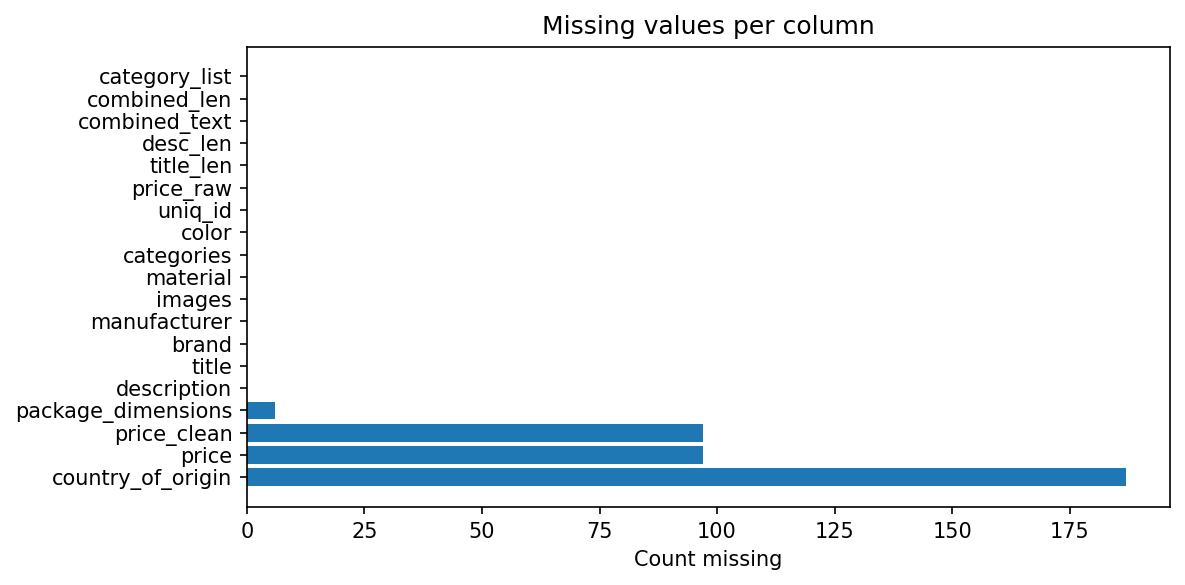

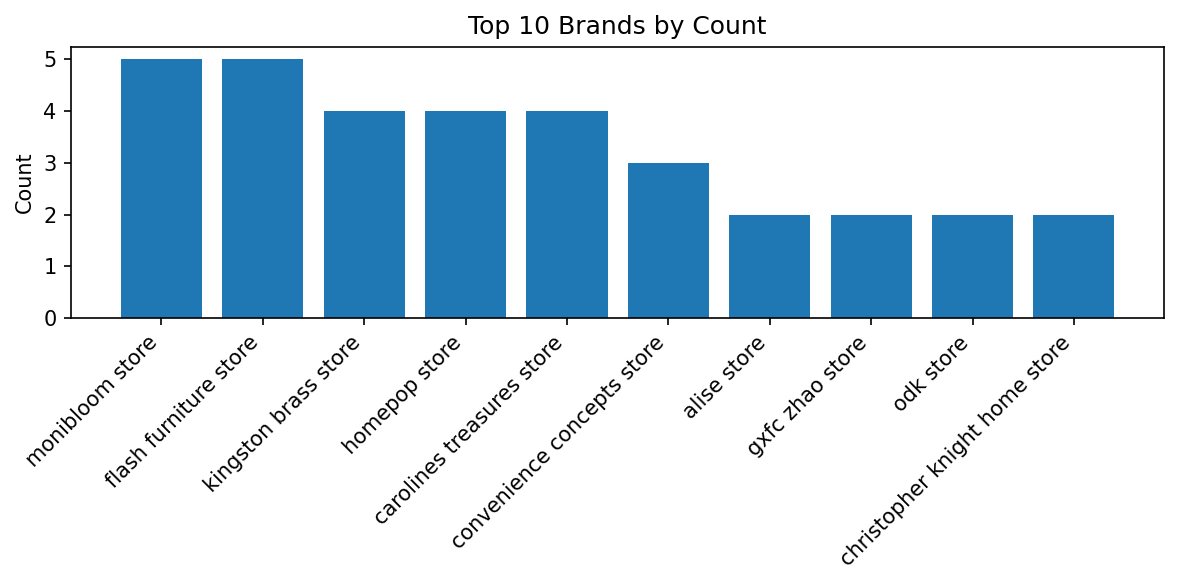

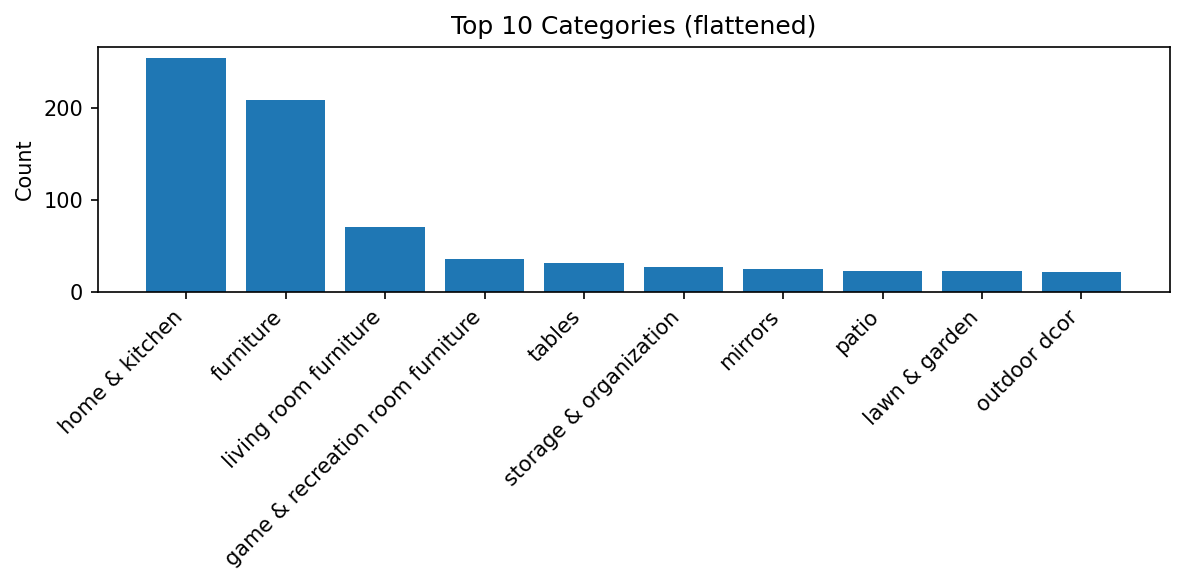

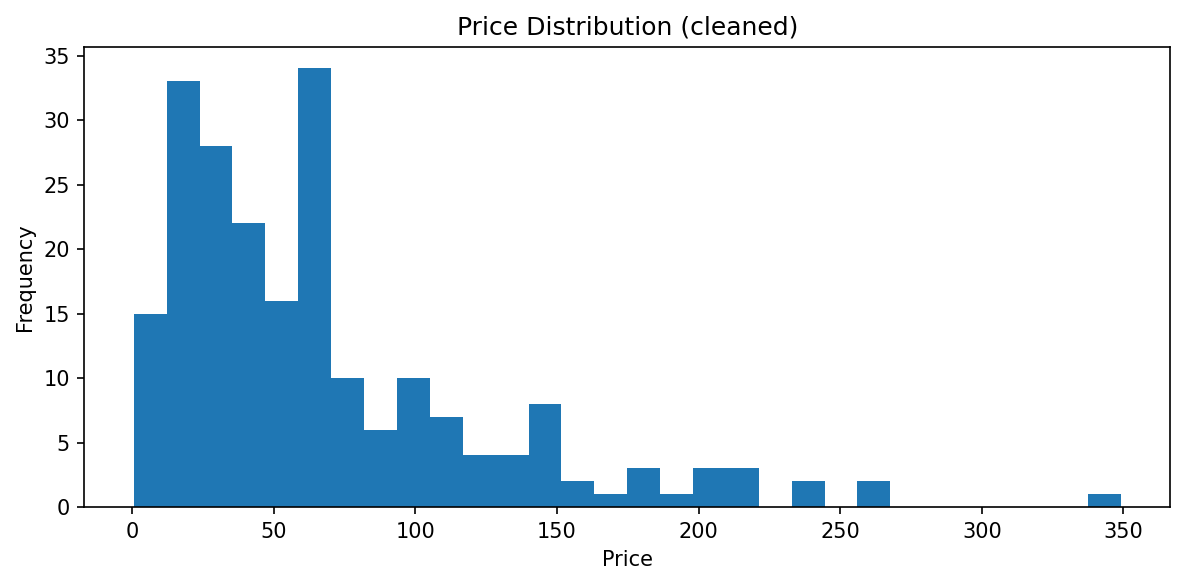

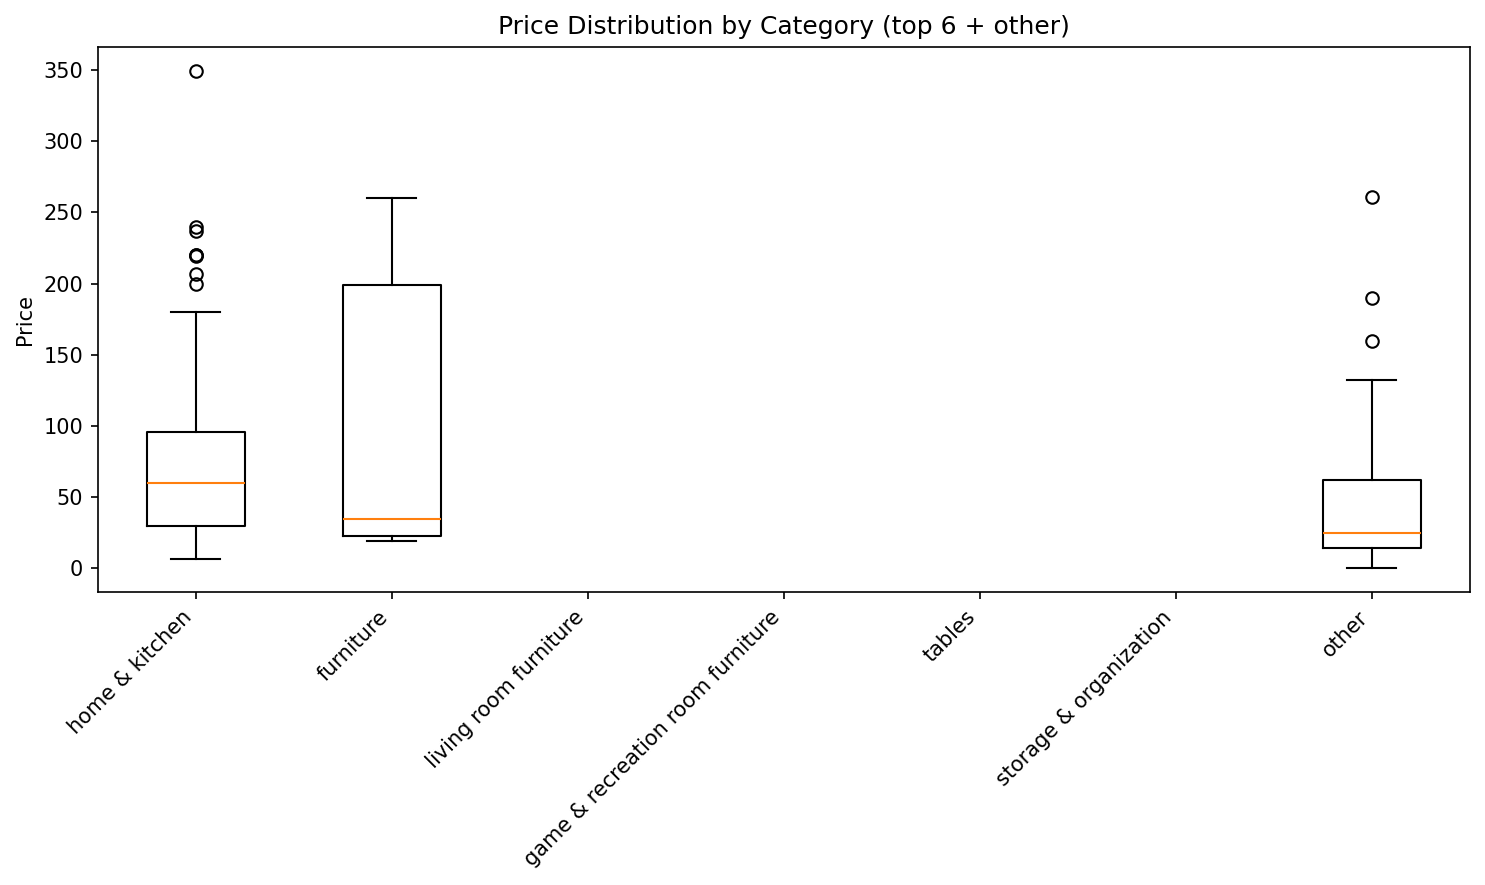

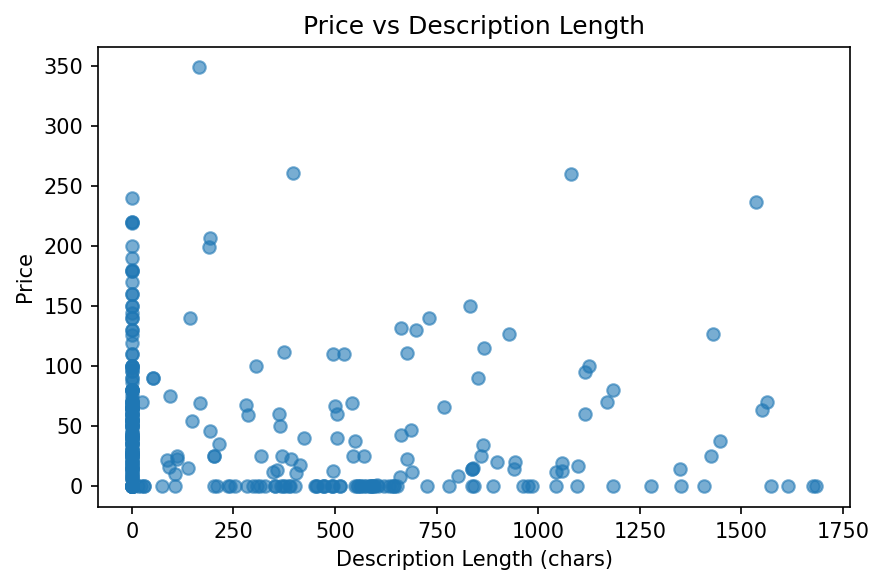

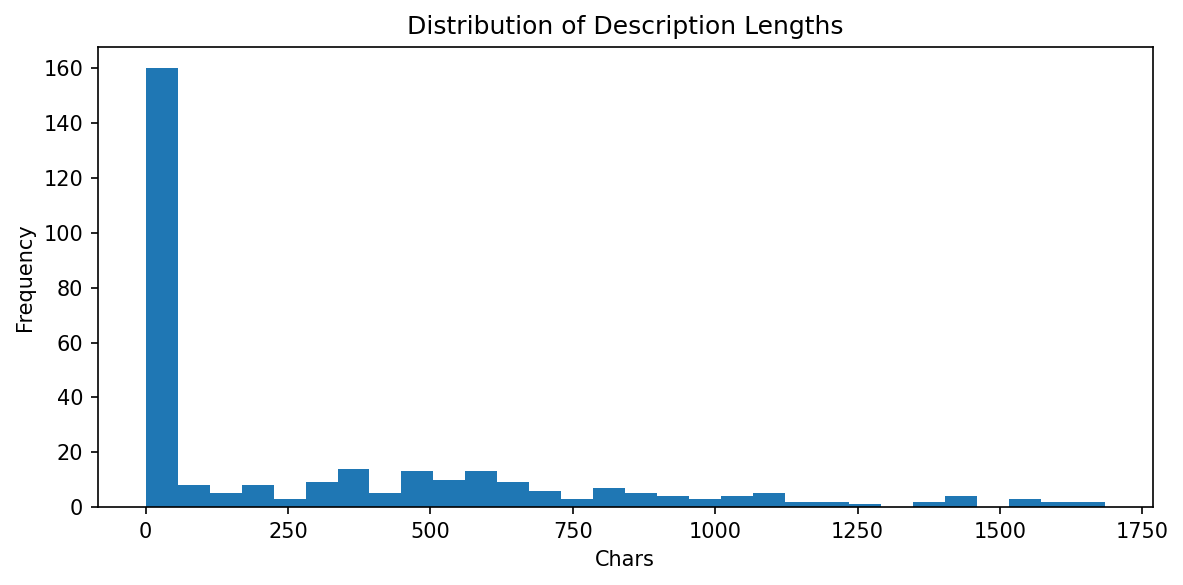

In [8]:
import matplotlib.pyplot as plt

# 1. Missingness per column
missing = df.isnull().sum().sort_values(ascending=False)
plt.figure(figsize=(8,4))
plt.barh(missing.index, missing.values)
plt.title("Missing values per column")
plt.xlabel("Count missing")
plt.tight_layout()
# plt.savefig(f"{FIGURE_DIR}/missing_per_column.png")
plt.show()

# 2. Top 10 brands
plt.figure(figsize=(8,4))
top_brands_plot = brand_counts.head(10)
plt.bar(top_brands_plot.index, top_brands_plot.values)
plt.title("Top 10 Brands by Count")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# plt.savefig(f"{FIGURE_DIR}/top_brands.png")
plt.show()

# 3. Top 10 categories (flattened)
plt.figure(figsize=(8,4))
top_cats = category_counts.head(10)
plt.bar(top_cats.index, top_cats.values)
plt.title("Top 10 Categories (flattened)")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# plt.savefig(f"{FIGURE_DIR}/top_categories.png")
plt.show()

# 4. Price distribution histogram
plt.figure(figsize=(8,4))
clean_prices = df['price_clean'].dropna()
plt.hist(clean_prices, bins=30)
plt.title("Price Distribution (cleaned)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
# plt.savefig(f"{FIGURE_DIR}/price_distribution.png")
plt.show()

# 5. Price boxplot by broad category (top 6)
top6 = top_categories['category_list'].tolist()[:6]

def first_top_category(cat_list):
    for c in cat_list:
        if c in top6:
            return c
    return 'other'

if len(top6)>0:
    df['main_top_cat'] = df['category_list'].apply(first_top_category)
    plt.figure(figsize=(10,6))
    box_data = [df.loc[df['main_top_cat']==c, 'price_clean'].dropna() for c in top6+['other']]
    plt.boxplot(box_data, tick_labels=top6+['other'])
    plt.title("Price Distribution by Category (top 6 + other)")
    plt.ylabel("Price")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    # plt.savefig(f"{FIGURE_DIR}/price_by_category.png")
    plt.show()

# 6. Scatter: price vs description length
plt.figure(figsize=(6,4))
plt.scatter(df['desc_len'], df['price_clean'].fillna(0), alpha=0.6)
plt.title("Price vs Description Length")
plt.xlabel("Description Length (chars)")
plt.ylabel("Price")
plt.tight_layout()
# plt.savefig(f"{FIGURE_DIR}/price_vs_desc_len.png")
plt.show()

# 7. Distribution of description length
plt.figure(figsize=(8,4))
plt.hist(df['desc_len'], bins=30)
plt.title("Distribution of Description Lengths")
plt.xlabel("Chars")
plt.ylabel("Frequency")
plt.tight_layout()
# plt.savefig(f"{FIGURE_DIR}/desc_len_distribution.png")
plt.show()


## Brand vs Category Crosstab

In [9]:
brand_counts = df['brand'].value_counts()
print('\nTop 10 brands:\n', brand_counts.head(10))


Top 10 brands:
 brand
monibloom store                  5
flash furniture store            5
kingston brass store             4
homepop store                    4
carolines treasures store        4
convenience concepts store       3
alise store                      2
gxfc zhao store                  2
odk store                        2
christopher knight home store    2
Name: count, dtype: int64


In [ ]:
# Crosstab of top brands vs main category
top_brand_list = top_brands['brand'].tolist()[:8]
df['brand_group'] = df['brand'].apply(lambda x: x if x in top_brand_list else 'other')
crosstab = pd.crosstab(df['brand_group'], df.get('main_top_cat', 'other'))

display(crosstab)
# # Save crosstab to CSV for reference
# crosstab.to_csv('brand_vs_category_crosstab.csv')
# print('Saved brand_vs_category_crosstab.csv')


## Save cleaned sample for embedding pipeline

In [11]:
clean_sample = df[['uniq_id','title','brand','description','price_clean','category_list','material','color','combined_text']].copy()
clean_sample.to_csv(OUTPUT_CLEANED_CSV, index=False)
print(f"Saved cleaned sample to {OUTPUT_CLEANED_CSV}")


Saved cleaned sample to ../data/clean_sample_for_embeddings.csv


## Notes and next steps
- You can use `clean_sample_for_embeddings.csv` as input to the embedding pipeline.
- If you plan to use a vector DB (like Pinecone), include `uniq_id` and `combined_text` when creating embeddings.
- Consider enriching missing `description` or `material` fields using a lightweight GenAI model before creating embeddings.